In [1]:
# ==========================================
# 1. IMPORTAR LIBRERÍAS
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

In [2]:
# Configuración visual
sns.set_theme(style="whitegrid")

# ==========================================
# 2. CARGAR Y EXPLORAR DATOS
# ==========================================
# Cargar datos desde la carpeta raw
df = pd.read_csv('../data/raw/Customer Churn.csv')

print("--- DIMENSIONES DEL DATASET ---")
print(f"Filas: {df.shape[0]}, Columnas: {df.shape[1]}\n")

print("--- PRIMERAS 5 FILAS ---")
display(df.head())

print("--- INFORMACIÓN DEL DATASET ---")
df.info()

--- DIMENSIONES DEL DATASET ---
Filas: 3150, Columnas: 14

--- PRIMERAS 5 FILAS ---


,Call Failure,Complains,Subscription Length,Charge Amount,Seconds of Use,Frequency of use,Frequency of SMS,Distinct Called Numbers,Age Group,Tariff Plan,Status,Age,Customer Value,Churn
0,8,0,38,0,4370,71,5,17,3,1,1,30,197.640,0
1,0,0,39,0,318,5,7,4,2,1,2,25,46.035,0
2,10,0,37,0,2453,60,359,24,3,1,1,30,1536.520,0
3,10,0,38,0,4198,66,1,35,1,1,1,15,240.020,0
4,3,0,38,0,2393,58,2,33,1,1,1,15,145.805,0


--- INFORMACIÓN DEL DATASET ---
<class 'pandas.DataFrame'>
RangeIndex: 3150 entries, 0 to 3149
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Call  Failure            3150 non-null   int64  
 1   Complains                3150 non-null   int64  
 2   Subscription  Length     3150 non-null   int64  
 3   Charge  Amount           3150 non-null   int64  
 4   Seconds of Use           3150 non-null   int64  
 5   Frequency of use         3150 non-null   int64  
 6   Frequency of SMS         3150 non-null   int64  
 7   Distinct Called Numbers  3150 non-null   int64  
 8   Age Group                3150 non-null   int64  
 9   Tariff Plan              3150 non-null   int64  
 10  Status                   3150 non-null   int64  
 11  Age                      3150 non-null   int64  
 12  Customer Value           3150 non-null   float64
 13  Churn                    3150 non-null   int64  
dtypes: 


--- VALORES NULOS POR COLUMNA ---
Call  Failure              0
Complains                  0
Subscription  Length       0
Charge  Amount             0
Seconds of Use             0
Frequency of use           0
Frequency of SMS           0
Distinct Called Numbers    0
Age Group                  0
Tariff Plan                0
Status                     0
Age                        0
Customer Value             0
Churn                      0
dtype: int64


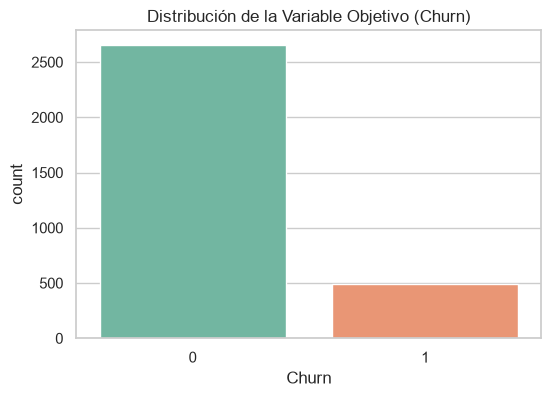

Proporción de Clases (%) :
Churn
0    84.285714
1    15.714286
Name: proportion, dtype: float64


In [7]:
# 3. ANÁLISIS EXPLORATORIO (EDA)
# ==========================================
print("\n--- VALORES NULOS POR COLUMNA ---")
print(df.isnull().sum())

# Distribución de la Variable Objetivo (Churn)
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Churn', palette='Set2')
plt.title('Distribución de la Variable Objetivo (Churn)')
plt.show()

print("Proporción de Clases (%) :")
print(df['Churn'].value_counts(normalize=True) * 100)

# ==========================================

In [4]:
# 4. ESTRATEGIA DE PREPROCESAMIENTO
# ==========================================
print("""
--- ESTRATEGIA DEFINIDA PARA EL PREPROCESAMIENTO ---
1. Imputación: Llenar los valores nulos de 'TotalCharges' con la mediana.
2. Limpieza: Eliminar la columna 'customerID' ya que no aporta valor predictivo.
3. Codificación (Encoding): 
   - Label Encoding para la variable objetivo 'Churn' (Yes=1, No=0).
   - One-Hot Encoding (OHE) para variables categóricas (InternetService, Contract, etc.).
4. Escalado: Aplicar StandardScaler a variables numéricas (Tenure, MonthlyCharges, TotalCharges) para algoritmos sensibles a la escala.
5. Balanceo: Considerar SMOTE o class_weights debido al desbalanceo (~73/27).
""")


--- ESTRATEGIA DEFINIDA PARA EL PREPROCESAMIENTO ---
1. Imputación: Llenar los valores nulos de 'TotalCharges' con la mediana.
2. Limpieza: Eliminar la columna 'customerID' ya que no aporta valor predictivo.
3. Codificación (Encoding): 
   - Label Encoding para la variable objetivo 'Churn' (Yes=1, No=0).
   - One-Hot Encoding (OHE) para variables categóricas (InternetService, Contract, etc.).
4. Escalado: Aplicar StandardScaler a variables numéricas (Tenure, MonthlyCharges, TotalCharges) para algoritmos sensibles a la escala.
5. Balanceo: Considerar SMOTE o class_weights debido al desbalanceo (~73/27).



In [8]:
# 5. ESTABLECER BASELINE DE RENDIMIENTO
# ==========================================
X = df.drop(columns=['Churn'])
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Modelo baseline (predice la clase mayoritaria)
dummy_clf = DummyClassifier(strategy="most_frequent")
dummy_clf.fit(X_train, y_train)
y_pred_dummy = dummy_clf.predict(X_test)

In [9]:
print("--- RESULTADOS DEL MODELO BASELINE (DUMMY CLASSIFIER) ---")
print(classification_report(y_test, y_pred_dummy, zero_division=0))
print(f"ROC-AUC Score Baseline: {roc_auc_score(y_test, dummy_clf.predict_proba(X_test)[:, 1]):.4f}")

--- RESULTADOS DEL MODELO BASELINE (DUMMY CLASSIFIER) ---
              precision    recall  f1-score   support

           0       0.84      1.00      0.91       531
           1       0.00      0.00      0.00        99

    accuracy                           0.84       630
   macro avg       0.42      0.50      0.46       630
weighted avg       0.71      0.84      0.77       630

ROC-AUC Score Baseline: 0.5000
